In [54]:
from ema_workbench import (
    Model,
    MultiprocessingEvaluator,
    ScalarOutcome,
    IntegerParameter,
    optimize,
    Scenario,
)
from ema_workbench.em_framework.optimization import EpsilonProgress
from ema_workbench.util import ema_logging
from problem_formulation import get_model_for_problem_formulation
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

<class 'ema_workbench.em_framework.model.Model'>


[MainProcess/INFO] pool started with 8 workers
100%|████████████████████████████████████████| 200/200 [00:05<00:00, 35.72it/s]
[MainProcess/INFO] optimization completed, found 89 solutions
[MainProcess/INFO] terminating pool


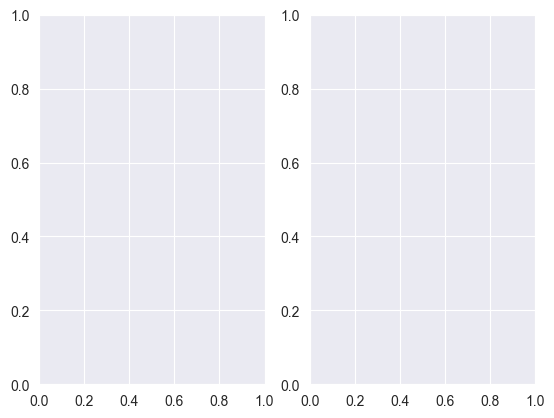

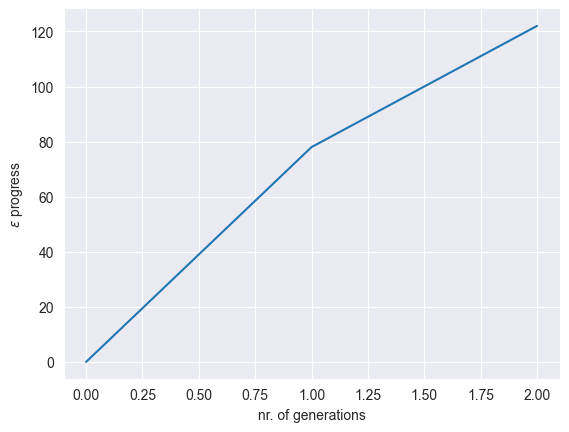

In [55]:
if __name__ == "__main__":
    ema_logging.log_to_stderr(ema_logging.INFO)

    model, steps = get_model_for_problem_formulation(3)
    print(type(model))

    reference_values = {
        "Bmax": 175,
        "Brate": 1.5,
        "pfail": 0.5,
        "discount rate 0": 3.5,
        "discount rate 1": 3.5,
        "discount rate 2": 3.5,
        "ID flood wave shape": 4,
    }
    scen1 = {}

    for key in model.uncertainties:
        name_split = key.name.split("_")

        if len(name_split) == 1:
            scen1.update({key.name: reference_values[key.name]})

        else:
            scen1.update({key.name: reference_values[name_split[1]]})

    ref_scenario = Scenario("reference", **scen1)

    convergence_metrics = [EpsilonProgress()]

    espilon = [1e3] * len(model.outcomes)

    nfe = 200  # proof of principle only, way to low for actual use

    with MultiprocessingEvaluator(model) as evaluator:
        results, convergence = evaluator.optimize(
            nfe=nfe,
            searchover="levers",
            epsilons=espilon,
            convergence=convergence_metrics,
            reference=ref_scenario,
        )

    fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True)
    fig, ax1 = plt.subplots(ncols=1)
    ax1.plot(convergence.epsilon_progress)
    ax1.set_xlabel("nr. of generations")
    ax1.set_ylabel(r"$\epsilon$ progress")
    sns.despine()


/Users/batuhantazegul/Documents/EPA/2425/Q4/EPA141A/aaaaaaa/ema_workbench/analysis/parcoords.py:220: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(h_pad=0, w_pad=0)


<Figure size 6000x1200 with 0 Axes>

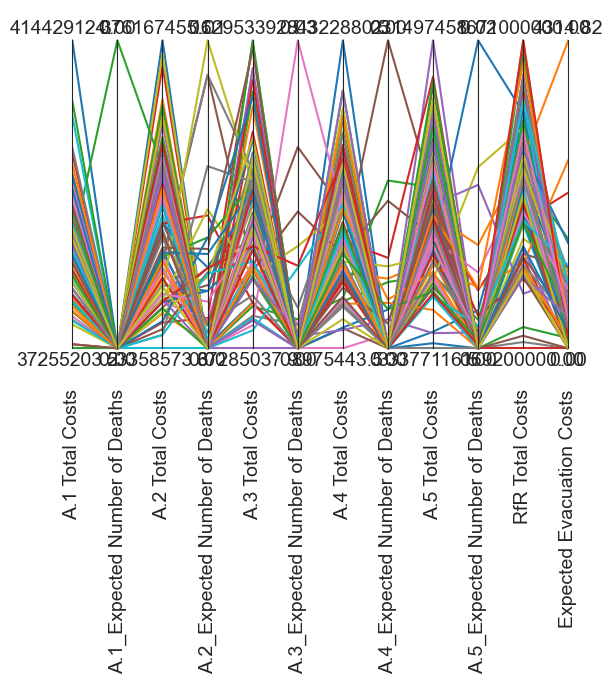

In [56]:
import matplotlib.pyplot as plt
from ema_workbench.analysis import parcoords

data = results.loc[:, [o.name for o in model.outcomes]]
limits = parcoords.get_limits(data)

plt.figure(figsize=(60, 12))  # make the figure wider; adjust numbers as you want

paraxes = parcoords.ParallelAxes(limits)
paraxes.plot(data)

plt.show()

In [57]:
import random
random.seed(20)

In [128]:
import os
from ema_workbench.em_framework.optimization import ArchiveLogger, EpsilonProgress
from ema_workbench import MultiprocessingEvaluator

# Zorg dat de map bestaat
os.makedirs("./archives", exist_ok=True)

# Verwijder bestaand bestand indien nodig
archive_path = "./archives/optimization.tar.gz"
if os.path.exists(archive_path):
    os.remove(archive_path)

# Convergence metrics
convergence_metrics = [
    ArchiveLogger(
        "./archives",
        [l.name for l in model.levers],
        [o.name for o in model.outcomes],
        base_filename="optimization.tar.gz",
    ),
    EpsilonProgress(),
]

# Run de optimalisatie
with MultiprocessingEvaluator(model) as evaluator:
    results, convergence = evaluator.optimize(
        nfe=1000,
        searchover='levers',
        convergence=convergence_metrics,
        epsilons=[0.01] * len(model.outcomes),
        reference=ref_scenario
    )

[MainProcess/INFO] pool started with 8 workers
100%|██████████████████████████████████████| 1000/1000 [00:30<00:00, 32.80it/s]
[MainProcess/INFO] optimization completed, found 226 solutions
[MainProcess/INFO] terminating pool


In [125]:
archives = ArchiveLogger.load_archives("./archives/optimization.tar.gz")

In [129]:
def calculate_convergence_metrics(problem, archives_file, reference_set):
    hv = HypervolumeMetric(reference_set, problem)
    metrics = []
    for nfe, archive in archives_file.items():
        scores = {"hypervolume": hv.calculate(archive),
                  "nfe": nfe}
        metrics.append(scores)
        print(metrics)
    df = pd.DataFrame.from_dict(metrics)
    df.sort_values(by="nfe", inplace=True, ignore_index=True)
    return df

# Test for one scenario

archive_test = ArchiveLogger.load_archives("./archives/optimization.tar.gz")
reference_set_test = results
print(f'reference set example 57 {reference_set_test}')


problem = to_problem(model, searchover="levers")

metrics = calculate_convergence_metrics(problem, archive_test, reference_set_test)
print(metrics)

reference set example 57      0_RfR 0  0_RfR 1  0_RfR 2  1_RfR 0  1_RfR 1  1_RfR 2  2_RfR 0  2_RfR 1  \
0          1        0        0        0        0        0        1        0   
1          1        0        0        1        1        0        0        0   
2          1        1        1        0        1        0        1        0   
3          1        0        1        1        1        0        0        0   
4          1        1        0        0        0        1        1        1   
..       ...      ...      ...      ...      ...      ...      ...      ...   
221        0        0        0        0        0        1        0        1   
222        0        1        1        0        0        1        1        1   
223        1        1        1        0        1        0        0        0   
224        0        1        1        0        1        1        1        0   
225        0        1        0        0        0        0        1        0   

     2_RfR 2  3_RfR 0  ...

EMAError: Parameter names ['0_RfR 0', '0_RfR 1', '0_RfR 2', '1_RfR 0', '1_RfR 1', '1_RfR 2', '2_RfR 0', '2_RfR 1', '2_RfR 2', '3_RfR 0', '3_RfR 1', '3_RfR 2', '4_RfR 0', '4_RfR 1', '4_RfR 2', 'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2', 'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2', 'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2', 'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2', 'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2'] not found in archive

In [63]:
from ema_workbench import HypervolumeMetric
from ema_workbench.em_framework.optimization import to_problem

# Step 1: Full reference set (all columns) required here
problem = to_problem(model, searchover="levers")

# Step 2: Only extract outcome names
outcome_names = [o.name for o in model.outcomes]

# Step 3: Use full reference set when constructing the metric (not subset)
hv = HypervolumeMetric(reference_set, problem)

# Step 4: Extract only outcome data for each archive when calculating
hypervolume = []

for nfe, archive in archives.items():
    try:
        # Outcome-only input here
        archive_outcomes = archive[outcome_names]
        hv_value = hv.calculate(archive_outcomes)
        hypervolume.append((nfe, hv_value))
    except Exception as e:
        print(f"❌ Skipping nfe={nfe} due to error: {e}")

hypervolume.sort(key=lambda x: x[0])
hypervolume = np.asarray(hypervolume)


EMAError: Parameter names ['0_RfR 0', '0_RfR 1', '0_RfR 2', '1_RfR 0', '1_RfR 1', '1_RfR 2', '2_RfR 0', '2_RfR 1', '2_RfR 2', '3_RfR 0', '3_RfR 1', '3_RfR 2', '4_RfR 0', '4_RfR 1', '4_RfR 2', 'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2', 'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2', 'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2', 'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2', 'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2'] not found in archive

In [5]:
for nfe, archive in archives.items():
    print(f"NFE {nfe}: {len(archive)} rows")

NameError: name 'archives' is not defined

In [10]:
results

,0_RfR 0,0_RfR 1,0_RfR 2,1_RfR 0,1_RfR 1,1_RfR 2,2_RfR 0,2_RfR 1,2_RfR 2,3_RfR 0,...,A.2 Total Costs,A.2_Expected Number of Deaths,A.3 Total Costs,A.3_Expected Number of Deaths,A.4 Total Costs,A.4_Expected Number of Deaths,A.5 Total Costs,A.5_Expected Number of Deaths,RfR Total Costs,Expected Evacuation Costs
0,0,0,0,0,0,0,1,1,1,1,...,2.306841e+08,0.002158,8.560912e+07,0.000000,6.590773e+07,0.000000,1.578034e+08,0.000000,4.694000e+08,168.722926
1,1,1,0,0,1,0,0,1,1,0,...,1.911013e+08,0.003495,1.467362e+08,0.000000,4.277965e+07,0.000000,1.077455e+08,0.001850,7.045000e+08,437.538933
2,1,0,0,0,0,1,1,0,1,0,...,1.831333e+08,0.000000,8.676551e+07,0.000000,2.727903e+07,0.001727,9.455149e+07,0.000000,3.638000e+08,0.000000
3,1,0,1,0,0,1,1,0,0,0,...,1.530433e+08,0.000000,6.231890e+07,0.000000,3.956834e+07,0.000000,1.086282e+08,0.000000,9.162000e+08,0.000000
4,1,0,0,0,1,0,0,1,1,0,...,1.372205e+08,0.000000,1.360111e+08,0.000000,5.243976e+07,0.000000,8.110585e+07,0.000000,6.199000e+08,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,1,1,0,0,0,1,0,0,1,1,...,1.292678e+08,0.004491,7.432910e+07,0.000000,1.637308e+07,0.000000,1.756989e+08,0.000000,1.051100e+09,349.365235
356,1,1,1,1,1,0,0,1,1,0,...,2.563460e+08,0.000000,4.473572e+07,0.003312,2.395362e+07,0.001393,1.359078e+08,0.026234,1.006900e+09,0.000000
357,1,0,0,0,0,0,1,0,0,0,...,1.963903e+08,0.000000,9.672814e+07,0.000000,2.826544e+07,0.000000,1.144608e+08,0.034324,3.714000e+08,0.000000
358,1,0,0,0,0,0,0,0,0,1,...,8.865996e+07,0.012919,7.826286e+07,0.043070,1.427866e+07,0.000106,1.205506e+08,0.000000,8.392000e+08,0.000000


In [18]:
print(dir(problem))

['MAXIMIZE', 'MINIMIZE', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'constraint_names', 'constraints', 'directions', 'ema_constraints', 'evaluate', 'function', 'nconstrs', 'nobjs', 'nvars', 'outcome_names', 'parameter_names', 'parameters', 'reference', 'searchover', 'types']


In [ ]:
results = []
with MultiprocessingEvaluator(model) as evaluator:
    # we run 5 seperate optimizations
    for _ in range(5):
        result = evaluator.optimize(
            nfe=5000, searchover="levers", epsilons=[0.05] * len(model.outcomes), reference=ref_scenario
        )
        results.append(result)

[MainProcess/INFO] pool started with 12 workers
  0%|                                                 | 0/5000 [00:00<?, ?it/s]

In [ ]:
from ema_workbench.em_framework.optimization import epsilon_nondominated, to_problem

problem = to_problem(model, searchover="levers")
epsilons = [0.05] * len(model.outcomes)
merged_archives = epsilon_nondominated(results, epsilons, problem)

In [ ]:
merged_archives.shape

In [ ]:
from ema_workbench.em_framework.optimization import ArchiveLogger, EpsilonProgress

# we need to store our results for each seed
results = []
convergences = []

with MultiprocessingEvaluator(model) as evaluator:
    # we run again for 5 seeds
    for i in range(5):
        # we create 2 covergence tracker metrics
        # the archive logger writes the archive to disk for every x nfe
        # the epsilon progress tracks during runtime
        convergence_metrics = [
            ArchiveLogger(
                "./archives",
                [l.name for l in model.levers],
                [o.name for o in model.outcomes],
                base_filename=f"{i}.tar.gz",
            ),
            EpsilonProgress(),
        ]

        result, convergence = evaluator.optimize(
            nfe=50000,
            searchover="levers",
            epsilons=[0.05] * len(model.outcomes),
            convergence=convergence_metrics,
            reference=ref_scenario
        )

        results.append(result)
        convergences.append(convergence)

In [ ]:
all_archives = []

for i in range(5):
    archives = ArchiveLogger.load_archives(f"./archives/{i}.tar.gz")
    all_archives.append(archives)

In [ ]:
from ema_workbench import (
    HypervolumeMetric,
    GenerationalDistanceMetric,
    EpsilonIndicatorMetric,
    InvertedGenerationalDistanceMetric,
    SpacingMetric,
)
from ema_workbench.em_framework.optimization import to_problem

problem = to_problem(model, searchover="levers")

reference_set = epsilon_nondominated(results, [0.05] * len(model.outcomes), problem)

hv = HypervolumeMetric(reference_set, problem)
gd = GenerationalDistanceMetric(reference_set, problem, d=1)
ei = EpsilonIndicatorMetric(reference_set, problem)
ig = InvertedGenerationalDistanceMetric(reference_set, problem, d=1)
sm = SpacingMetric(problem)


metrics_by_seed = []
for archives in all_archives:
    metrics = []
    for nfe, archive in archives.items():
        scores = {
            "generational_distance": gd.calculate(archive),
            "hypervolume": hv.calculate(archive),
            "epsilon_indicator": ei.calculate(archive),
            "inverted_gd": ig.calculate(archive),
            "spacing": sm.calculate(archive),
            "nfe": int(nfe),
        }
        metrics.append(scores)
    metrics = pd.DataFrame.from_dict(metrics)

    # sort metrics by number of function evaluations
    metrics.sort_values(by="nfe", inplace=True)
    metrics_by_seed.append(metrics)

In [ ]:
sns.set_style("white")
fig, axes = plt.subplots(nrows=6, figsize=(8, 12), sharex=True)

ax1, ax2, ax3, ax4, ax5, ax6 = axes

for metrics, convergence in zip(metrics_by_seed, convergences):
    ax1.plot(metrics.nfe, metrics.hypervolume)
    ax1.set_ylabel("hypervolume")

    ax2.plot(convergence.nfe, convergence.epsilon_progress)
    ax2.set_ylabel("$\epsilon$ progress")

    ax3.plot(metrics.nfe, metrics.generational_distance)
    ax3.set_ylabel("generational distance")

    ax4.plot(metrics.nfe, metrics.epsilon_indicator)
    ax4.set_ylabel("epsilon indicator")

    ax5.plot(metrics.nfe, metrics.inverted_gd)
    ax5.set_ylabel("inverted generational\ndistance")

    ax6.plot(metrics.nfe, metrics.spacing)
    ax6.set_ylabel("spacing")

ax6.set_xlabel("nfe")


sns.despine(fig)

plt.show()

C:\Users\milan\PycharmProjects\EMAworkbench\ema_workbench\analysis\parcoords.py:220: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(h_pad=0, w_pad=0)


<Figure size 6000x3000 with 0 Axes>

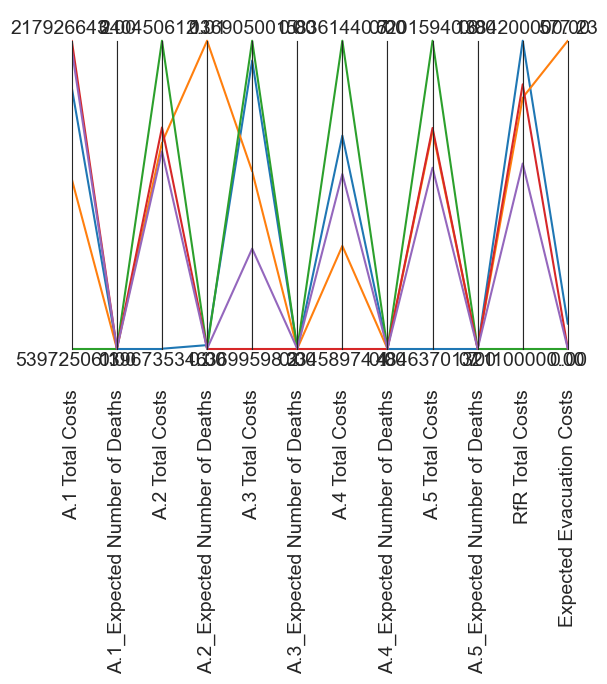

In [25]:
import matplotlib.pyplot as plt
from ema_workbench.analysis import parcoords

data = results.loc[:, [o.name for o in model.outcomes]]

# Define thresholds for "low" values, here using the 10th percentile for each
threshold_deaths = data['A.5_Expected Number of Deaths'].quantile(0.1)
threshold_costs = data['A.5 Total Costs'].quantile(0.1)

# Filter rows where both outcomes are below their thresholds
filtered_data = data[
    (data['A.5_Expected Number of Deaths'] <= threshold_deaths) &
    (data['A.5 Total Costs'] <= threshold_costs)
]

limits = parcoords.get_limits(filtered_data)

plt.figure(figsize=(60, 30))  # wide figure

paraxes = parcoords.ParallelAxes(limits)
paraxes.plot(filtered_data)

plt.show()

In [28]:
# Calculate 10th percentile thresholds for each column
threshold_costs = results['A.5 Total Costs'].quantile(0.1)
threshold_deaths = results['A.5_Expected Number of Deaths'].quantile(0.1)

# Filter rows where both are below the thresholds
filtered_results = results[
    (results['A.5 Total Costs'] <= threshold_costs) &
    (results['A.5_Expected Number of Deaths'] <= threshold_deaths)
]

In [29]:
filtered_results

,0_RfR 0,0_RfR 1,0_RfR 2,1_RfR 0,1_RfR 1,1_RfR 2,2_RfR 0,2_RfR 1,2_RfR 2,3_RfR 0,...,A.2 Total Costs,A.2_Expected Number of Deaths,A.3 Total Costs,A.3_Expected Number of Deaths,A.4 Total Costs,A.4_Expected Number of Deaths,A.5 Total Costs,A.5_Expected Number of Deaths,RfR Total Costs,Expected Evacuation Costs
7,1,1,1,1,1,0,1,0,1,0,...,1.396735e+08,0.000087,1.321846e+08,0.0,5.069078e+07,0.0,4.846370e+07,0.0,1.384200e+09,46.613192
13,1,1,1,1,1,0,0,0,0,1,...,2.070968e+08,0.007404,1.058509e+08,0.0,4.177288e+07,0.0,5.804407e+07,0.0,1.187900e+09,577.226412
26,1,1,0,0,0,0,0,0,1,0,...,2.404506e+08,0.000000,1.369050e+08,0.0,5.836144e+07,0.0,6.201594e+07,0.0,3.211000e+08,0.000000
43,1,0,1,0,1,0,1,1,1,1,...,2.120685e+08,0.000000,6.369960e+07,0.0,3.345897e+07,0.0,5.817663e+07,0.0,1.233700e+09,0.000000
63,0,0,1,0,0,0,0,0,0,1,...,2.042489e+08,0.000000,8.749894e+07,0.0,4.758096e+07,0.0,5.642588e+07,0.0,9.604000e+08,0.000000


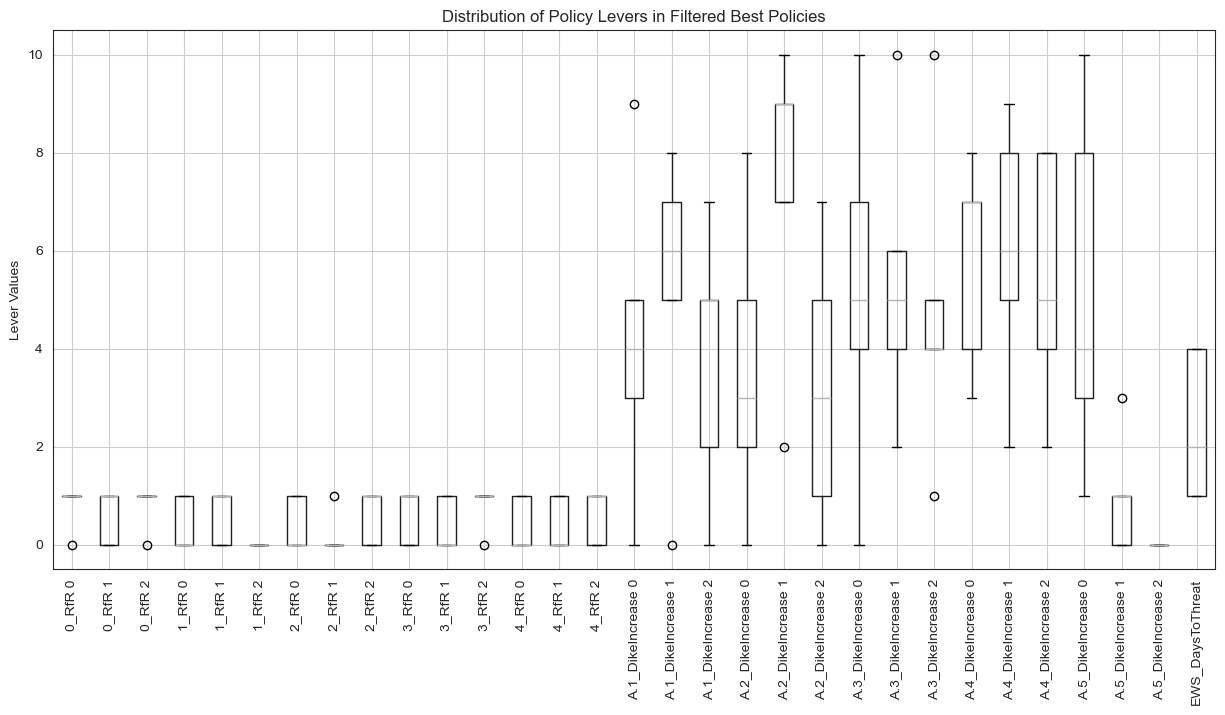

In [30]:
import matplotlib.pyplot as plt

# Assuming filtered_results is your filtered DataFrame from before

# List of policy levers (same as you provided)
policy_levers = [
    '0_RfR 0', '0_RfR 1', '0_RfR 2', '1_RfR 0', '1_RfR 1', '1_RfR 2',
    '2_RfR 0', '2_RfR 1', '2_RfR 2', '3_RfR 0', '3_RfR 1', '3_RfR 2',
    '4_RfR 0', '4_RfR 1', '4_RfR 2',
    'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2',
    'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2',
    'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2',
    'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2',
    'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2',
    'EWS_DaysToThreat'
]

# Check if all levers exist in filtered_results columns (optional)
existing_levers = [lever for lever in policy_levers if lever in filtered_results.columns]

# Plot boxplot for those policy levers
plt.figure(figsize=(15, 7))
filtered_results[existing_levers].boxplot(rot=90)
plt.title("Distribution of Policy Levers in Filtered Best Policies")
plt.ylabel("Lever Values")
plt.show()

###stap 3

In [65]:
results

,0_RfR 0,0_RfR 1,0_RfR 2,1_RfR 0,1_RfR 1,1_RfR 2,2_RfR 0,2_RfR 1,2_RfR 2,3_RfR 0,...,A.2 Total Costs,A.2_Expected Number of Deaths,A.3 Total Costs,A.3_Expected Number of Deaths,A.4 Total Costs,A.4_Expected Number of Deaths,A.5 Total Costs,A.5_Expected Number of Deaths,RfR Total Costs,Expected Evacuation Costs
0,1,0,0,0,0,1,1,0,1,0,...,1.831333e+08,0.000000,8.676551e+07,0.000000,2.754888e+07,0.001908,9.455149e+07,0.000000,3.638000e+08,0.000000
1,1,0,0,0,1,0,0,1,1,0,...,1.372205e+08,0.000000,1.360111e+08,0.000000,5.243976e+07,0.000000,8.110585e+07,0.000000,6.199000e+08,0.000000
2,1,0,1,1,0,0,1,1,1,1,...,1.997049e+08,0.000000,5.176004e+07,0.000000,5.419577e+07,0.000000,8.454688e+07,0.000000,8.564000e+08,0.000000
3,0,1,0,0,0,0,1,0,0,0,...,3.441051e+08,0.000000,1.174267e+08,0.000000,7.627547e+07,0.000000,7.214135e+07,0.002174,2.365000e+08,197.006196
4,0,0,1,0,0,0,1,0,0,1,...,2.655508e+08,0.000000,9.899910e+07,0.000000,1.108250e+07,0.000865,9.059544e+07,0.000000,7.487000e+08,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270,0,1,1,0,1,1,0,1,0,1,...,1.403743e+08,0.000647,8.511197e+07,0.000000,5.512113e+07,0.000000,1.173399e+08,0.000000,1.511300e+09,195.345189
271,0,0,0,0,0,0,0,1,1,0,...,1.854388e+08,0.000928,1.082908e+08,0.003203,2.760443e+07,0.001358,1.373947e+08,0.000000,6.140000e+07,426.186580
272,0,0,0,0,0,0,0,1,0,1,...,1.793765e+08,0.006239,1.347894e+08,0.000000,1.841585e+07,0.002550,1.244709e+08,0.000000,2.731000e+08,0.000000
273,0,1,1,0,0,1,1,0,0,1,...,1.449155e+08,0.002592,1.163686e+08,0.000000,1.900949e+07,0.001283,1.827284e+08,0.000000,6.601000e+08,0.000000


In [78]:
logical = (
    (results['A.5_Expected Number of Deaths'] < 1e-32) &
    (results['A.5 Total Costs'] < 50000000)
)

np.sum(logical)  # counts how many rows satisfy both conditions


np.int64(5)

In [79]:
results[logical]

,0_RfR 0,0_RfR 1,0_RfR 2,1_RfR 0,1_RfR 1,1_RfR 2,2_RfR 0,2_RfR 1,2_RfR 2,3_RfR 0,...,A.2 Total Costs,A.2_Expected Number of Deaths,A.3 Total Costs,A.3_Expected Number of Deaths,A.4 Total Costs,A.4_Expected Number of Deaths,A.5 Total Costs,A.5_Expected Number of Deaths,RfR Total Costs,Expected Evacuation Costs
87,1,0,0,1,0,1,1,1,0,1,...,2.039861e+08,0.000000,9.970639e+07,0.000000,3.802639e+07,0.000000,4.419351e+07,0.0,1.080100e+09,0.000000
97,0,0,1,1,0,0,1,1,1,1,...,5.318856e+07,0.004267,6.559958e+07,0.000000,1.656309e+07,0.000000,3.667668e+07,0.0,6.369000e+08,334.890499
177,1,0,1,0,0,0,1,0,0,1,...,2.272878e+08,0.000000,6.689379e+07,0.003656,3.218694e+07,0.000056,4.027367e+07,0.0,4.423000e+08,526.548362
227,0,0,1,1,0,0,1,1,1,1,...,1.520582e+08,0.004099,8.469446e+07,0.000000,1.409224e+07,0.000000,3.337712e+07,0.0,1.526400e+09,0.000000
246,0,0,0,1,0,0,1,1,1,1,...,1.929854e+08,0.005927,8.081689e+07,0.000000,2.627848e+07,0.000000,3.337712e+07,0.0,8.084000e+08,0.000000


In [80]:
policies = results[logical]
policies = policies.drop([o.name for o in model.outcomes], axis=1)
policies

,0_RfR 0,0_RfR 1,0_RfR 2,1_RfR 0,1_RfR 1,1_RfR 2,2_RfR 0,2_RfR 1,2_RfR 2,3_RfR 0,...,A.2_DikeIncrease 2,A.3_DikeIncrease 0,A.3_DikeIncrease 1,A.3_DikeIncrease 2,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2
87,1,0,0,1,0,1,1,1,0,1,...,10,7,4,2,3,2,9,7,0,0
97,0,0,1,1,0,0,1,1,1,1,...,2,2,0,9,3,2,0,5,0,0
177,1,0,1,0,0,0,1,0,0,1,...,1,0,2,6,1,6,4,6,0,0
227,0,0,1,1,0,0,1,1,1,1,...,5,1,7,2,0,2,1,4,0,0
246,0,0,0,1,0,0,1,1,1,1,...,10,1,6,2,5,1,1,4,0,0


In [81]:
from ema_workbench import Policy

policies_to_evaluate = []

for i, policy in policies.iterrows():
    policies_to_evaluate.append(Policy(str(i), **policy.to_dict()))

In [82]:
n_scenarios = 1000
with MultiprocessingEvaluator(model) as evaluator:
    results = evaluator.perform_experiments(n_scenarios,
                                            policies_to_evaluate)

[MainProcess/INFO] pool started with 8 workers
[MainProcess/INFO] performing 1000 scenarios * 5 policies * 1 model(s) = 5000 experiments
100%|██████████████████████████████████████| 5000/5000 [02:32<00:00, 32.88it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] terminating pool


In [83]:
def s_to_n(data, direction):
    mean = np.mean(data)
    std = np.std(data)

    if direction==ScalarOutcome.MAXIMIZE:
        return mean/std
    else:
        return mean*std

In [84]:
experiments, outcomes = results

overall_scores = {}
for policy in np.unique(experiments['policy']):
    scores = {}

    logical = experiments['policy']==policy

    for outcome in model.outcomes:
        value  = outcomes[outcome.name][logical]
        sn_ratio = s_to_n(value, outcome.kind)
        scores[outcome.name] = sn_ratio
    overall_scores[policy] = scores
scores = pd.DataFrame.from_dict(overall_scores).T
scores

,A.1 Total Costs,A.1_Expected Number of Deaths,A.2 Total Costs,A.2_Expected Number of Deaths,A.3 Total Costs,A.3_Expected Number of Deaths,A.4 Total Costs,A.4_Expected Number of Deaths,A.5 Total Costs,A.5_Expected Number of Deaths,RfR Total Costs,Expected Evacuation Costs
177,3.611175e+13,7.920555e-12,7.920972e+14,2.827726e-08,4.414051e+16,1.818672e-03,3.055660e+14,1.599497e-07,8.937959e+14,7.527574e-07,0.0,5.532055e+07
227,5.453515e+15,4.081862e-05,1.002975e+16,9.622056e-04,4.293986e+15,7.509224e-04,1.191657e+14,2.688642e-06,1.001455e+15,6.958442e-05,0.0,0.000000e+00
246,2.092513e+16,1.576015e-04,1.352253e+16,1.177149e-03,5.518938e+15,1.467744e-03,8.275693e+13,2.888999e-07,1.691045e+15,2.625695e-04,0.0,0.000000e+00
87,7.384027e+00,0.000000e+00,9.138072e+15,4.239492e-06,1.444697e+14,9.076435e-09,2.010670e+14,2.291028e-08,7.592209e+14,2.619508e-07,0.0,1.985060e+06
97,0.000000e+00,0.000000e+00,1.520691e+16,8.334845e-04,5.083383e+15,2.577116e-04,1.663841e+14,5.477427e-07,1.218339e+15,1.025918e-05,0.0,1.023561e+07


/Users/batuhantazegul/Documents/EPA/2425/Q4/EPA141A/aaaaaaa/ema_workbench/analysis/parcoords.py:220: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(h_pad=0, w_pad=0)


<Figure size 6000x1200 with 0 Axes>

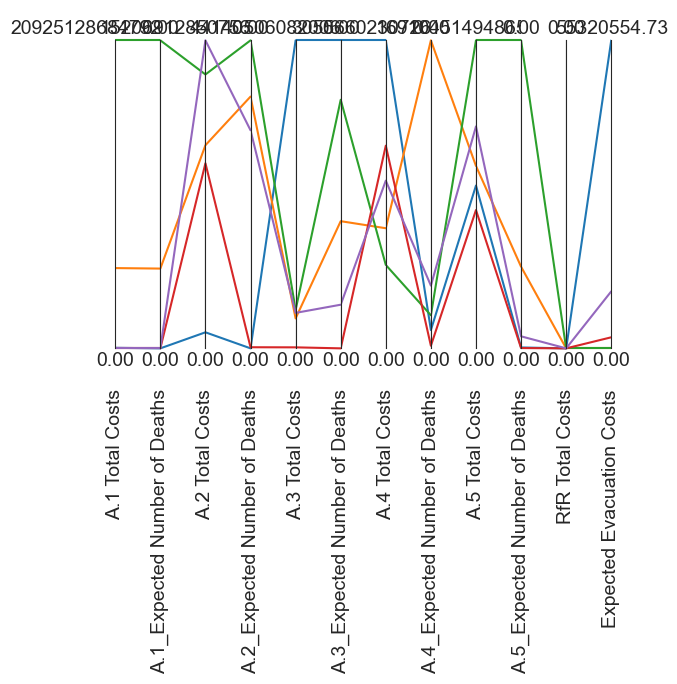

In [99]:
import matplotlib.pyplot as plt
from ema_workbench.analysis import parcoords

data = scores
limits = parcoords.get_limits(data)
limits.loc[0, [
    'A.1 Total Costs',
    'A.1_Expected Number of Deaths',
    'A.2 Total Costs',
    'A.2_Expected Number of Deaths',
    'A.3 Total Costs',
    'A.3_Expected Number of Deaths',
    'A.4 Total Costs',
    'A.4_Expected Number of Deaths',
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths',
    'RfR Total Costs',
    'Expected Evacuation Costs'
]] = 0


plt.figure(figsize=(60, 12))  # make the figure wider; adjust numbers as you want

paraxes = parcoords.ParallelAxes(limits)
paraxes.plot(data)
#paraxes.invert_axis('A.5_Expected Number of Deaths')
plt.show()
#nog even duidelijker  maken

<Figure size 1200x600 with 0 Axes>

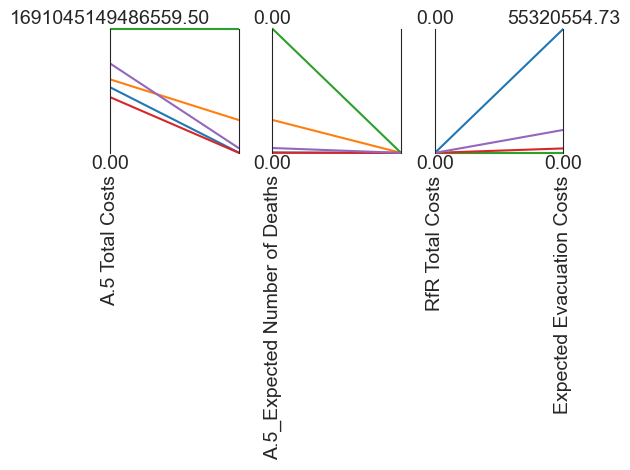

In [109]:
import matplotlib.pyplot as plt
from ema_workbench.analysis import parcoords

# Define the selected outcomes to focus on
selected_outcomes = [
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths',
    'RfR Total Costs',
    'Expected Evacuation Costs'
]

# Filter the data to only include selected outcomes
filtered_data = scores[selected_outcomes]

# Get limits and set lower bounds to 0
limits = parcoords.get_limits(filtered_data)
limits.loc[0, selected_outcomes] = 0

# Create the plot
plt.figure(figsize=(12, 6))  # Adjusted to match reduced number of axes

paraxes = parcoords.ParallelAxes(limits)
paraxes.plot(filtered_data)

# Optionally invert axes if you want low deaths to be visually higher
# paraxes.invert_axis('A.5_Expected Number of Deaths')

plt.tight_layout()
plt.show()


In [88]:
def calculate_regret(data, best):
    return np.abs(best-data)

In [89]:
experiments, outcomes = results

overall_regret = {}
max_regret = {}
for outcome in model.outcomes:
    policy_column = experiments['policy']

    # create a DataFrame with all the relevent information
    # i.e., policy, scenario_id, and scores
    data = pd.DataFrame({outcome.name: outcomes[outcome.name],
                         "policy":experiments['policy'],
                         "scenario":experiments['scenario']})

    # reorient the data by indexing with policy and scenario id
    data = data.pivot(index='scenario', columns='policy')

    # flatten the resulting hierarchical index resulting from
    # pivoting, (might be a nicer solution possible)
    data.columns = data.columns.get_level_values(1)

    # we need to control the broadcasting.
    # max returns a 1d vector across scenario id. By passing
    # np.newaxis we ensure that the shape is the same as the data
    # next we take the absolute value
    #
    # basically we take the difference of the maximum across
    # the row and the actual values in the row
    #
    outcome_regret = (data.max(axis=1).values[:, np.newaxis] - data).abs()

    overall_regret[outcome.name] = outcome_regret
    max_regret[outcome.name] = outcome_regret.max()

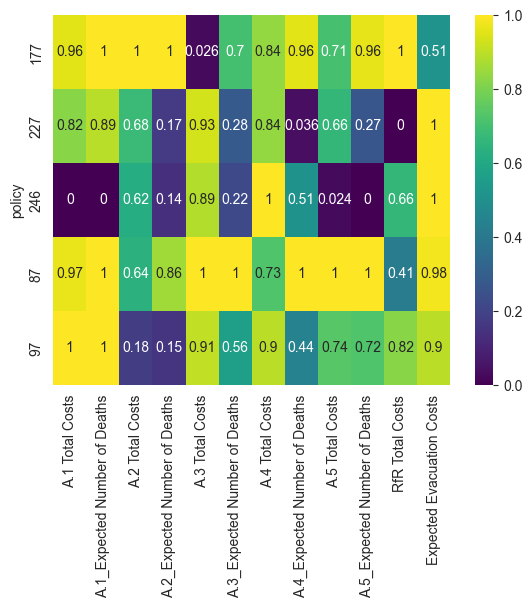

In [90]:
max_regret = pd.DataFrame(max_regret)
sns.heatmap(max_regret/max_regret.max(), cmap='viridis', annot=True)
plt.show()

/Users/batuhantazegul/Documents/EPA/2425/Q4/EPA141A/aaaaaaa/ema_workbench/analysis/parcoords.py:220: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(h_pad=0, w_pad=0)
/Users/batuhantazegul/Documents/EPA/2425/Q4/EPA141A/aaaaaaa/ema_workbench/analysis/parcoords.py:281: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(h_pad=0, w_pad=0)


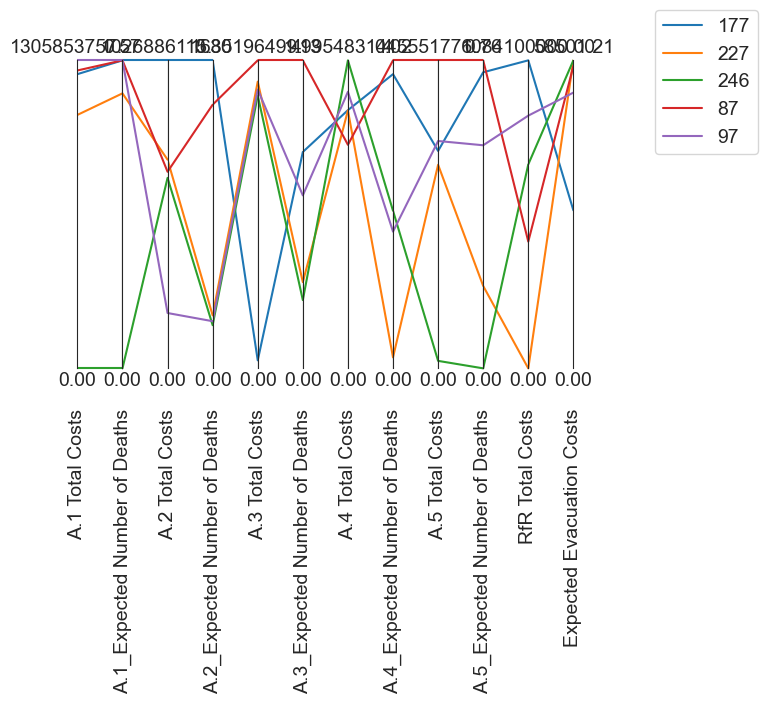

In [98]:
colors = sns.color_palette()

data = max_regret

# makes it easier to identify the policy associated with each line
# in the parcoords plot
# data['policy'] = data.index.astype("float64")

limits = parcoords.get_limits(data)
limits.loc[0, [
    'A.1 Total Costs',
    'A.1_Expected Number of Deaths',
    'A.2 Total Costs',
    'A.2_Expected Number of Deaths',
    'A.3 Total Costs',
    'A.3_Expected Number of Deaths',
    'A.4 Total Costs',
    'A.4_Expected Number of Deaths',
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths',
    'RfR Total Costs',
    'Expected Evacuation Costs'
]] = 0


paraxes = parcoords.ParallelAxes(limits)
for i, (index, row) in enumerate(data.iterrows()):
    paraxes.plot(row.to_frame().T, label=str(index), color=colors[i])
paraxes.legend()

plt.show()

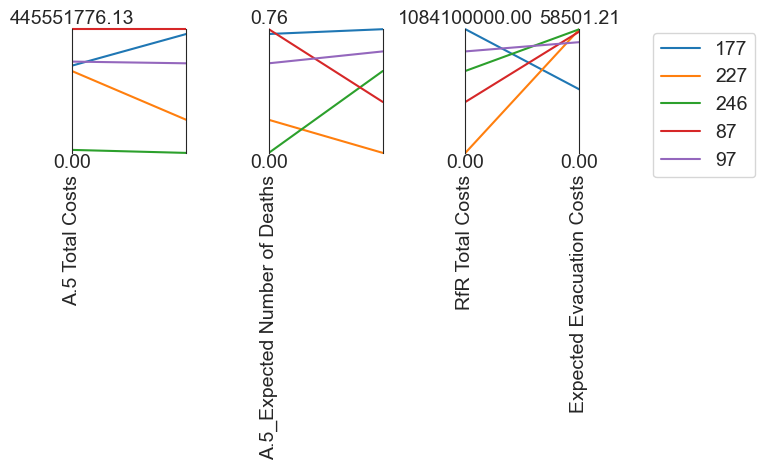

In [108]:
#betere leesbaarheid dan de vorige
import seaborn as sns
from ema_workbench.analysis import parcoords

colors = sns.color_palette()

# Select only the outcomes you want to plot
selected_outcomes = [
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths',
    'RfR Total Costs',
    'Expected Evacuation Costs'
]

# Filter the data to just those columns
data = max_regret[selected_outcomes]

# Set limits, and force minimums to 0
limits = parcoords.get_limits(data)
limits.loc[0, selected_outcomes] = 0  # Force y-axis minimums

# Create and draw parallel coordinate plot
paraxes = parcoords.ParallelAxes(limits)

for i, (index, row) in enumerate(data.iterrows()):
    paraxes.plot(row.to_frame().T, label=str(index), color=colors[i % len(colors)])

paraxes.legend()
plt.tight_layout()
plt.show()


In [100]:
from collections import defaultdict

policy_regret = defaultdict(dict)
for key, value in overall_regret.items():
    for policy in value:
        policy_regret[policy][key] = value[policy]

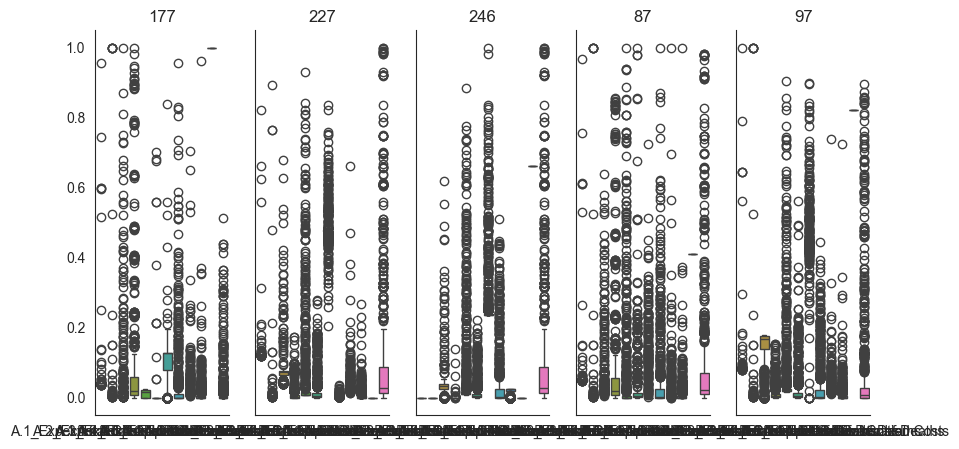

In [102]:
# this generates a 2 plots with a shared y and x axis
fig, axes = plt.subplots(ncols=5, figsize=(10,5),
                         sharey=True, sharex=True)

# to ensure easy iteration over the axes grid, we turn it
# into a list. Because there are four plots, I hard coded
# this.


# zip allows us to zip together the list of axes and the list of
# key value pairs return by items. If we iterate over this
# it returns a tuple of length 2. The first item is the ax
# the second items is the key value pair.
for ax, (policy, regret) in zip(axes, policy_regret.items()):
    data = pd.DataFrame(regret)

    # we need to scale the regret to ensure fair visual
    # comparison. We can do that by divding by the maximum regret
    data = data/max_regret.max(axis=0)
    sns.boxplot(data=data, ax=ax)

    # removes top and left hand black outline of axes
    sns.despine()

    # ensure we know which policy the figure is for
    ax.set_title(str(policy))
plt.show()

Leesbaarheid beter in de onderste alleen op a5 en algemene resultaten gefocust

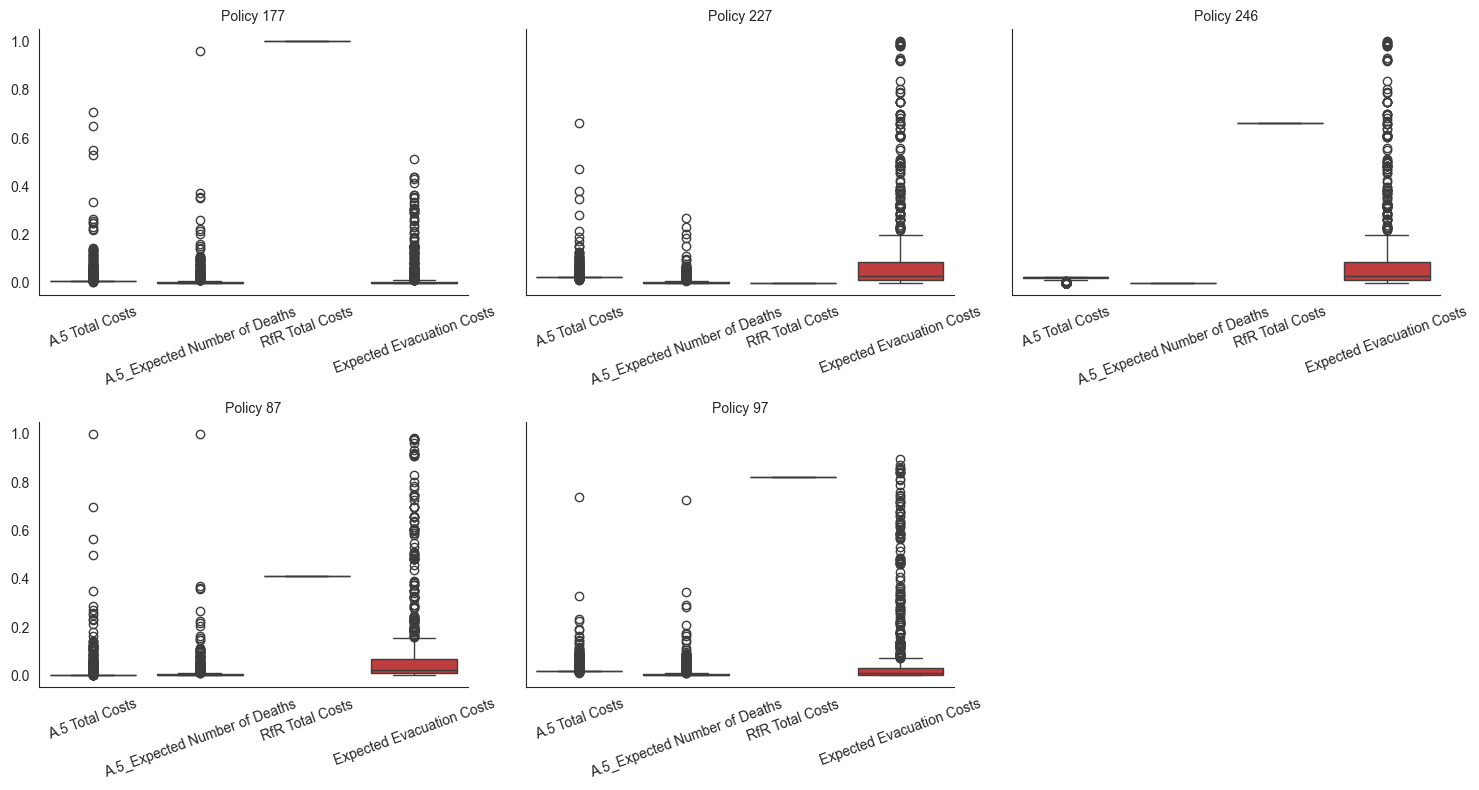

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

selected_outcomes = [
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths',
    'RfR Total Costs',
    'Expected Evacuation Costs'
]

# Calculate number of policies
num_policies = len(policy_regret)
ncols = 3  # columns in grid
nrows = int(np.ceil(num_policies / ncols))  # rows in grid

# Create grid of subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4), sharey=True)

# Flatten axes for easier indexing
axes = axes.flatten()

# Loop through policies and plot
for ax, (policy, regret) in zip(axes, policy_regret.items()):
    data = pd.DataFrame(regret)
    data = data / max_regret.max(axis=0)
    data = data[selected_outcomes]

    sns.boxplot(data=data, ax=ax)
    ax.set_title(f"Policy {policy}", fontsize=10)
    ax.tick_params(axis='x', labelrotation=20)  # Rotate labels for readability
    sns.despine()

# Hide unused axes if any
for ax in axes[len(policy_regret):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()



Prim


In [120]:
from ema_workbench.analysis import prim

x = experiments.drop(columns=[
    '0_RfR 0', '0_RfR 1', '0_RfR 2', '1_RfR 0', '1_RfR 1', '1_RfR 2',
    '2_RfR 0', '2_RfR 1', '2_RfR 2', '3_RfR 0', '3_RfR 1', '3_RfR 2',
    '4_RfR 0', '4_RfR 1', '4_RfR 2',
    'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2',
    'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2',
    'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2',
    'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2',
    'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2',
    'EWS_DaysToThreat','policy'
])
y = outcomes['A.5_Expected Number of Deaths'] < 0.0000005

prim_alg = prim.Prim(x, y, threshold=0.2)
box = prim_alg.find_box()

[MainProcess/INFO] column model dropped from analysis because it has only one category
[MainProcess/INFO] 5000 points remaining, containing 4330 cases of interest
[MainProcess/INFO] mean: 1.0, mass: 0.595, coverage: 0.687066974595843, density: 1.0 restricted_dimensions: 1


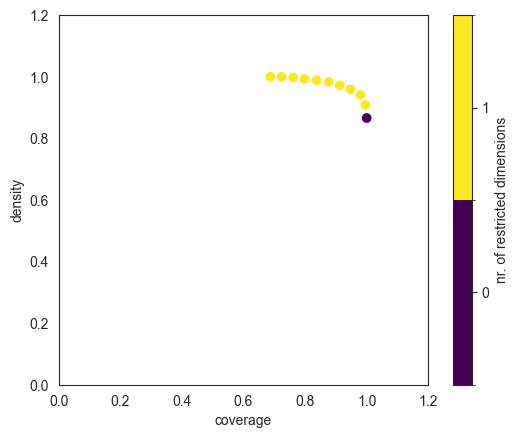

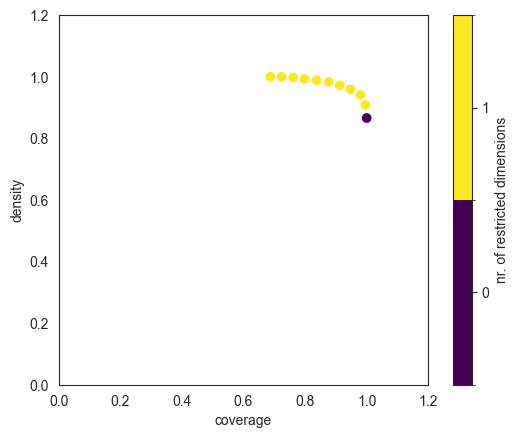

In [121]:
box.show_tradeoff()


In [124]:
box.inspect(3)


coverage       0.947806
density        0.958879
id             3.000000
k           4104.000000
mass           0.856000
mean           0.958879
n           4280.000000
res_dim        1.000000
Name: 3, dtype: float64

              box 3                                 
                min       max      qp value qp value
A.5_pfail  0.144178  0.999546  2.175732e-93      NaN



[None]